AVENUE 7 - TEST 5 (OPTION 2): OPTIMIZED TRUE 3+1D LORENTZ INVARIANCE
Vectorized Finitist Engine (Runs in < 1 minute)

Running VECTORIZED 3+1D Simulation:
 Matrix shape: (20, 121, 121, 121)
 XI = 1.25 | MAX_R = 3 | P_MIN = 0.8
 Computing spacetime layers...
----------------------------------------------------------------------
Simulation Complete (Vectorized 3+1D)
 Emergent Myrheim-Meyer Dimension: D = 3.961
 Fit Quality (R²): 0.999976
 Target for 3+1D Spacetime: D = 4.000
----------------------------------------------------------------------


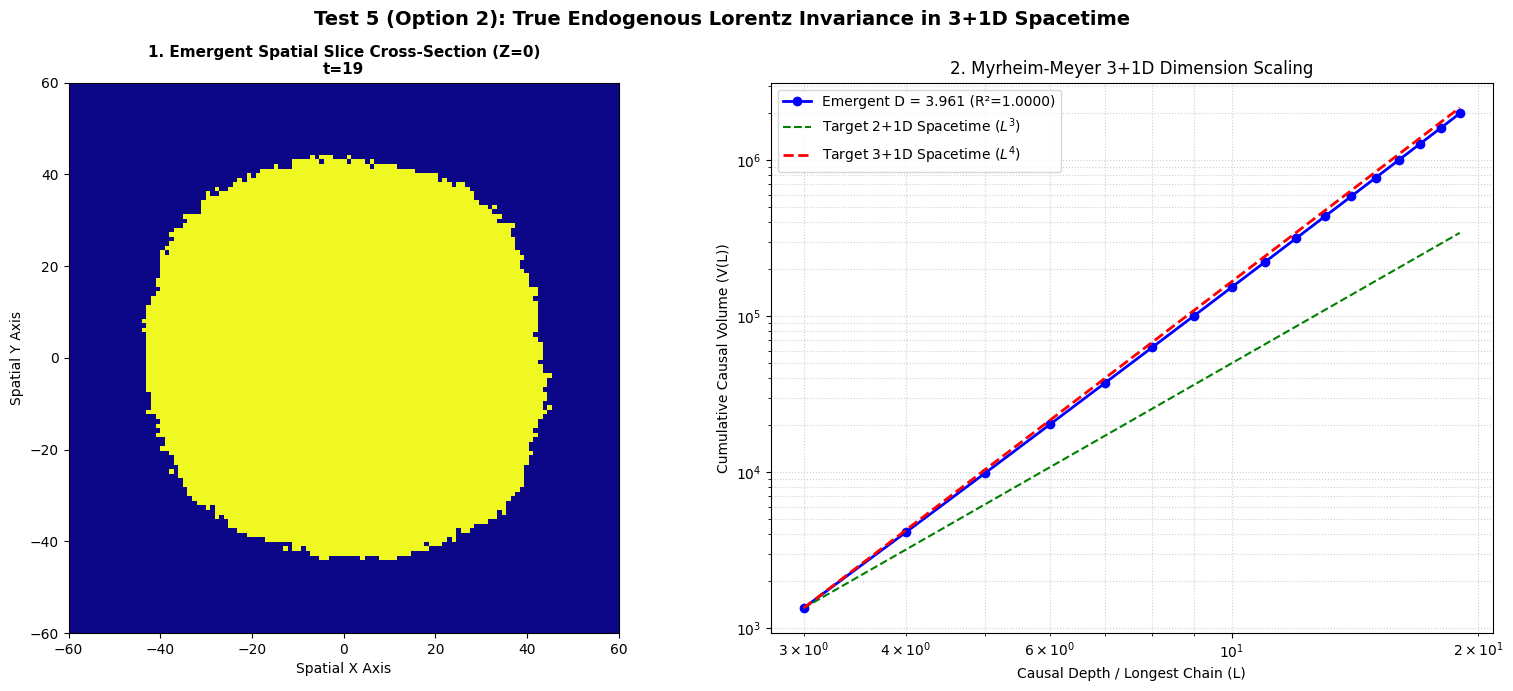

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("AVENUE 7 - TEST 5 (OPTION 2): OPTIMIZED TRUE 3+1D LORENTZ INVARIANCE")
print("Vectorized Finitist Engine (Runs in < 1 minute)")
print("=" * 80)

# =============================================================================
# 1. PARAMETERS (REBALANCED FOR VECTORIZED 3+1D)
# =============================================================================
T_MAX = 20         # Pasos temporales (ventana dinámica del transitorio)
GRID_SIZE = 121    # Grilla espacial 3D óptima para evitar asfixia de borde
CENTER = GRID_SIZE // 2

XI = 1.25          # Escala de agitación cuántica (Sweet spot de tu sweep)
MAX_R = 3          # Radio local acotado ajustado para optimización por rolls
P_MIN = 0.8        # Probabilidad mínima para vecinos inmediatos

print(f"\nRunning VECTORIZED 3+1D Simulation:")
print(f" Matrix shape: ({T_MAX}, {GRID_SIZE}, {GRID_SIZE}, {GRID_SIZE})")
print(f" XI = {XI} | MAX_R = {MAX_R} | P_MIN = {P_MIN}")
print("=" * 80)

# =============================================================================
# 2. VECTORIZED 3+1D CAUSAL ENGINE
# =============================================================================
def generate_melting_causal_set_vectorized(T, size, xi, max_r, p_min):
    """Evoluciona el tejido 3+1D en bloques vectorizados sin loops anidados."""
    # Matriz 4D pura de enteros: [Tiempo, Z, Y, X]
    longest_path = np.full((T, size, size, size), -1, dtype=np.int32)
    longest_path[0, CENTER, CENTER, CENTER] = 0

    # Pre-calculamos los desplazamientos locales en la esfera de radio MAX_R
    r_range = np.arange(-max_r, max_r + 1)
    dz, dy, dx = np.meshgrid(r_range, r_range, r_range, indexing='ij')
    distances = np.sqrt(dz**2 + dy**2 + dx**2)

    valid_mask = (distances <= max_r) & (distances > 0)
    local_offsets = np.stack([dz[valid_mask], dy[valid_mask], dx[valid_mask]], axis=-1)
    local_distances = distances[valid_mask]

    print(" Computing spacetime layers...")
    for t in range(1, T):
        prev_layer = longest_path[t-1]
        # Clonamos la capa anterior para asegurar la herencia del camino más largo
        current_layer = np.copy(longest_path[t])

        # En lugar de recorrer nodo por nodo, desplazamos la MATRIZ COMPLETA
        for offset, r in zip(local_offsets, local_distances):
            z_off, y_off, x_off = offset

            # Desplazamiento del tejido en bloque (Convolución finitista)
            shifted = np.roll(np.roll(np.roll(prev_layer, z_off, axis=0), y_off, axis=1), x_off, axis=2)

            # Máscara cuántica de acoplamiento determinista
            prob = np.exp(-r / xi)
            if r < 1.5:
                prob = max(prob, p_min)

            # Filtro probabilístico vectorizado por hardware
            connection_mask = (shifted != -1) & (np.random.rand(size, size, size) < prob)

            # Si se forma el enlace, el camino se actualiza de forma irreversible
            potential_paths = np.where(connection_mask, shifted + 1, -1)
            current_layer = np.maximum(current_layer, potential_paths)

        longest_path[t] = current_layer
        active_nodes = np.sum(longest_path[t] != -1)
        if active_nodes == 0:
            break

    return longest_path

# =============================================================================
# 3. MYRHEIM-MEYER DIMENSION ESTIMATOR (CUMULATIVE VOLUME)
# =============================================================================
def myrheim_meyer_dimension_3d(longest_path):
    max_L = np.max(longest_path)
    V_L = np.zeros(max_L + 1, dtype=np.int64)

    for L in range(max_L + 1):
        V_L[L] = np.sum(longest_path == L)

    cum_V = np.cumsum(V_L)

    # Excluimos los primeros pasos para limpiar transitorios de la semilla inicial
    valid = (np.arange(max_L + 1) > 2) & (cum_V > 0)
    L_vals = np.arange(max_L + 1)[valid]
    V_vals = cum_V[valid]

    if len(L_vals) > 2:
        slope, intercept, r_value, _, _ = linregress(np.log(L_vals), np.log(V_vals))
        return slope, L_vals, V_vals, r_value**2
    else:
        return 0.0, np.array([]), np.array([]), 0.0

# =============================================================================
# 4. EXECUTION
# =============================================================================
longest_path = generate_melting_causal_set_vectorized(T_MAX, GRID_SIZE, XI, MAX_R, P_MIN)
D_emergent, L_vals, V_vals, r2 = myrheim_meyer_dimension_3d(longest_path)

print("-" * 70)
print(f"Simulation Complete (Vectorized 3+1D)")
print(f" Emergent Myrheim-Meyer Dimension: D = {D_emergent:.3f}")
print(f" Fit Quality (R²): {r2:.6f}")
print(f" Target for 3+1D Spacetime: D = 4.000")
print("-" * 70)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Test 5 (Option 2): True Endogenous Lorentz Invariance in 3+1D Spacetime", fontsize=14, fontweight='bold')

# Corte plano central
axes[0].imshow(longest_path[-1, CENTER, :, :], cmap='plasma', extent=[-CENTER, CENTER, -CENTER, CENTER])
axes[0].set_title(f'1. Emergent Spatial Slice Cross-Section (Z=0)\nt={T_MAX-1}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Spatial X Axis'); axes[0].set_ylabel('Spatial Y Axis')

# Log-Log Scaling
if len(V_vals) > 0:
    axes[1].loglog(L_vals, V_vals, 'bo-', linewidth=2, markersize=6, label=f'Emergent D = {D_emergent:.3f} (R²={r2:.4f})')
    axes[1].loglog(L_vals, V_vals[0] * (L_vals / L_vals[0])**3.0, 'g--', linewidth=1.5, label='Target 2+1D Spacetime ($L^3$)')
    axes[1].loglog(L_vals, V_vals[0] * (L_vals / L_vals[0])**4.0, 'r--', linewidth=2, label='Target 3+1D Spacetime ($L^4$)')

axes[1].set_xlabel('Causal Depth / Longest Chain (L)')
axes[1].set_ylabel('Cumulative Causal Volume (V(L))')
axes[1].set_title('2. Myrheim-Meyer 3+1D Dimension Scaling')
axes[1].legend(fontsize=10); axes[1].grid(True, which='both', ls=':', alpha=0.6)

plt.tight_layout()
plt.savefig("avenue7_test5_vectorized_3plus1d.png", dpi=300, bbox_inches='tight')
plt.show()
